In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_rows', 50)

## 1. Data Understanding

In [3]:
data = pd.read_csv('train.csv')
df = pd.DataFrame(data)
df.head(3)

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0
1,1,2013-01-01,1,BABY CARE,0.00,0
2,2,2013-01-01,1,BEAUTY,0.00,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 196.8 MB


In [5]:
df.describe()

,id,store_nbr,sales,onpromotion
count,"3,000,888.00","3,000,888.00","3,000,888.00","3,000,888.00"
mean,"1,500,443.50",27.50,357.78,2.60
std,"866,281.89",15.59,"1,102.00",12.22
min,0.00,1.00,0.00,0.00
25%,"750,221.75",14.00,0.00,0.00
50%,"1,500,443.50",27.50,11.00,0.00
75%,"2,250,665.25",41.00,195.85,0.00
max,"3,000,887.00",54.00,"124,717.00",741.00


In [6]:
df.shape

(3000888, 6)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe(include=["object"])

C:\Users\Irvan N\AppData\Local\Temp\ipykernel_3880\3753758486.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=["object"])


,date,family
count,3000888,3000888
unique,1684,33
top,2013-01-01,AUTOMOTIVE
freq,1782,90936


In [ ]:
# persentase missing values tiap kolom
(df.isnull().sum() / len(df)) * 100

id            0.00
date          0.00
store_nbr     0.00
family        0.00
sales         0.00
onpromotion   0.00
dtype: float64

In [10]:
# Mengambil kolom kategorikal
cat_col = df.select_dtypes(include=['object']).columns

cat_info = []

for col in cat_col:
    cat_info.append({
        'column_name': col,
        'n_unique': df[col].nunique(),
        'sample_unique_values': df[col].dropna().unique()[:10].tolist()
    })

# Membuat dataframe
df_cat_info = pd.DataFrame(cat_info)

# Menampilkan
df_cat_info

C:\Users\Irvan N\AppData\Local\Temp\ipykernel_3880\3592911707.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df.select_dtypes(include=['object']).columns


,column_name,n_unique,sample_unique_values
0,date,1684,"[2013-01-01, 2013-01-02, 2013-01-03, 2013-01-0..."
1,family,33,"[AUTOMOTIVE, BABY CARE, BEAUTY, BEVERAGES, BOO..."


In [11]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n===== {col} =====")
    print(df[col].unique())


===== date =====
<ArrowStringArray>
['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04', '2013-01-05',
 '2013-01-06', '2013-01-07', '2013-01-08', '2013-01-09', '2013-01-10',
 ...
 '2017-08-06', '2017-08-07', '2017-08-08', '2017-08-09', '2017-08-10',
 '2017-08-11', '2017-08-12', '2017-08-13', '2017-08-14', '2017-08-15']
Length: 1684, dtype: str

===== family =====
<ArrowStringArray>
[                'AUTOMOTIVE',                  'BABY CARE',
                     'BEAUTY',                  'BEVERAGES',
                      'BOOKS',               'BREAD/BAKERY',
                'CELEBRATION',                   'CLEANING',
                      'DAIRY',                       'DELI',
                       'EGGS',               'FROZEN FOODS',
                  'GROCERY I',                 'GROCERY II',
                   'HARDWARE',         'HOME AND KITCHEN I',
        'HOME AND KITCHEN II',            'HOME APPLIANCES',
                  'HOME CARE',                 'LADIESWEAR',


C:\Users\Irvan N\AppData\Local\Temp\ipykernel_3880\1774054245.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


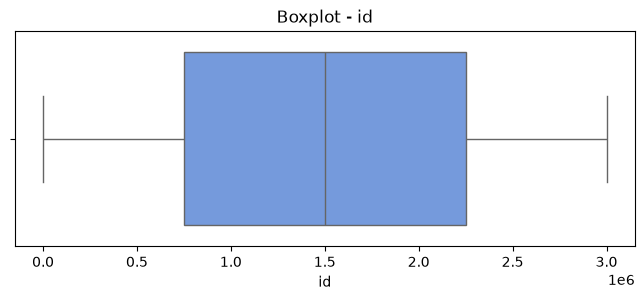

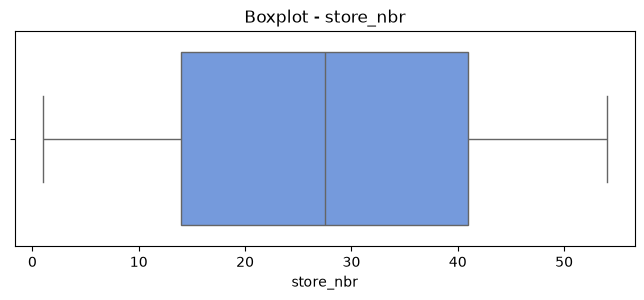

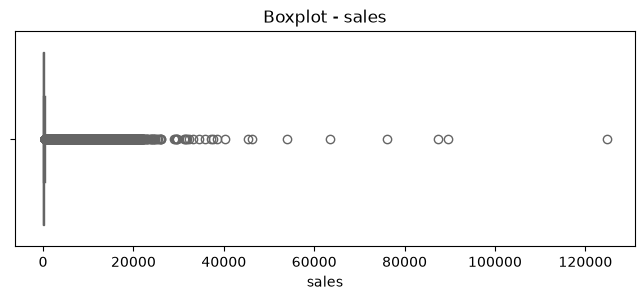

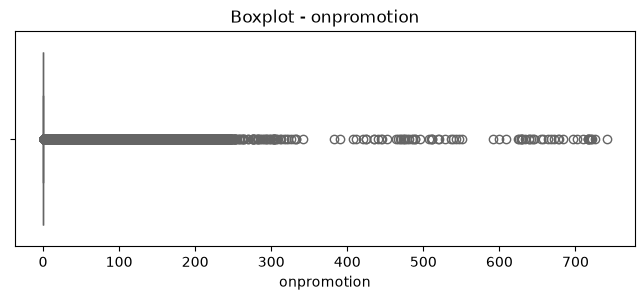

In [12]:
# Visualisasi Boxplot per Kolom Numerik

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(8, 2.8))
    sns.boxplot(x=df[col], color='cornflowerblue')
    plt.title(f'Boxplot - {col}')
    plt.xlabel(col)
    plt.show()

In [13]:
df['date'] = pd.to_datetime(df['date'])

In [14]:
df.set_index('date', inplace=True)

In [15]:
df.head()

,id,store_nbr,family,sales,onpromotion
date,,,,,
2013-01-01,0,1,AUTOMOTIVE,0.00,0
2013-01-01,1,1,BABY CARE,0.00,0
2013-01-01,2,1,BEAUTY,0.00,0
2013-01-01,3,1,BEVERAGES,0.00,0
2013-01-01,4,1,BOOKS,0.00,0


In [16]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

In [ ]:
# Kelompokkan data berdasarkan tanggal, lalu jumlahkan total sales-nya per hari
df_daily = df.groupby('date')['sales'].sum().reset_index()
df_daily.set_index('date', inplace=True)

print(df_daily.head())
print(f"Total baris sekarang: {len(df_daily)} hari")

                sales
date                 
2013-01-01   2,511.62
2013-01-02 496,092.42
2013-01-03 361,461.23
2013-01-04 354,459.68
2013-01-05 477,350.12
Total baris sekarang: 1684 hari


In [18]:
df_daily.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1684 entries, 2013-01-01 to 2017-08-15
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sales   1684 non-null   float64
dtypes: float64(1)
memory usage: 26.3 KB


In [73]:
from scipy.stats import normaltest

def dagostino_test(data, nama_kolom):
    sample = data.sample(
        n=min(10000, len(data)),
        random_state=42
    )

    stat, p = normaltest(sample)

    print("="*60)
    print(f"UJI NORMALITAS D'AGOSTINO : {nama_kolom}")
    print("="*60)
    print(f"Statistic : {stat:.4f}")
    print(f"P-value   : {p:.6f}")

    if p > 0.05:
        print("Kesimpulan : Berdistribusi normal")
    else:
        print("Kesimpulan : Tidak berdistribusi normal")

dagostino_test(df['sales'], 'Sales')
dagostino_test(df['onpromotion'], 'On Promotion')

UJI NORMALITAS D'AGOSTINO : Sales
Statistic : 12469.5315
P-value   : 0.000000
Kesimpulan : Tidak berdistribusi normal
UJI NORMALITAS D'AGOSTINO : On Promotion
Statistic : 18234.0819
P-value   : 0.000000
Kesimpulan : Tidak berdistribusi normal


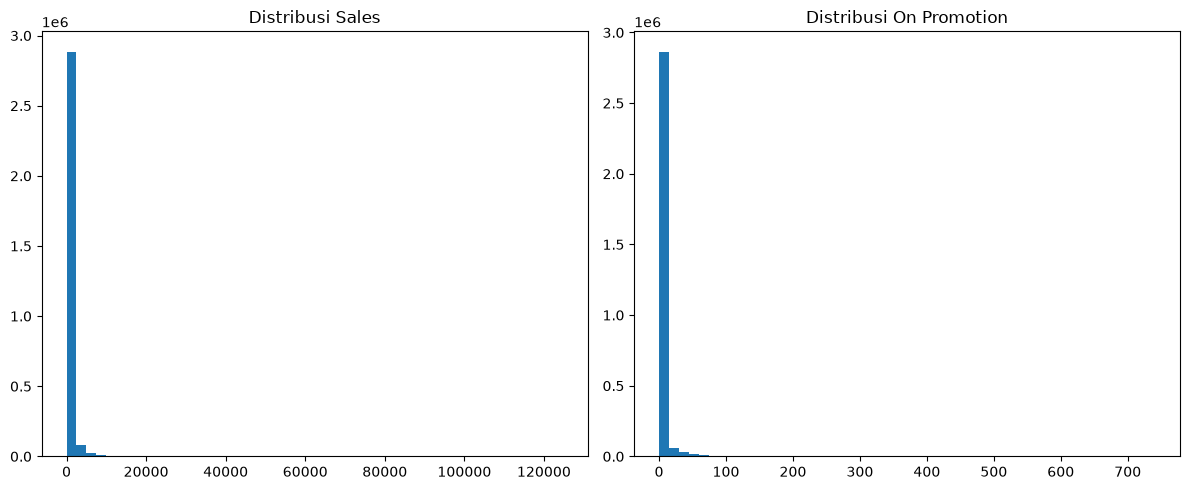

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df['sales'], bins=50)
plt.title("Distribusi Sales")

plt.subplot(1,2,2)
plt.hist(df['onpromotion'], bins=50)
plt.title("Distribusi On Promotion")

plt.tight_layout()
plt.show()

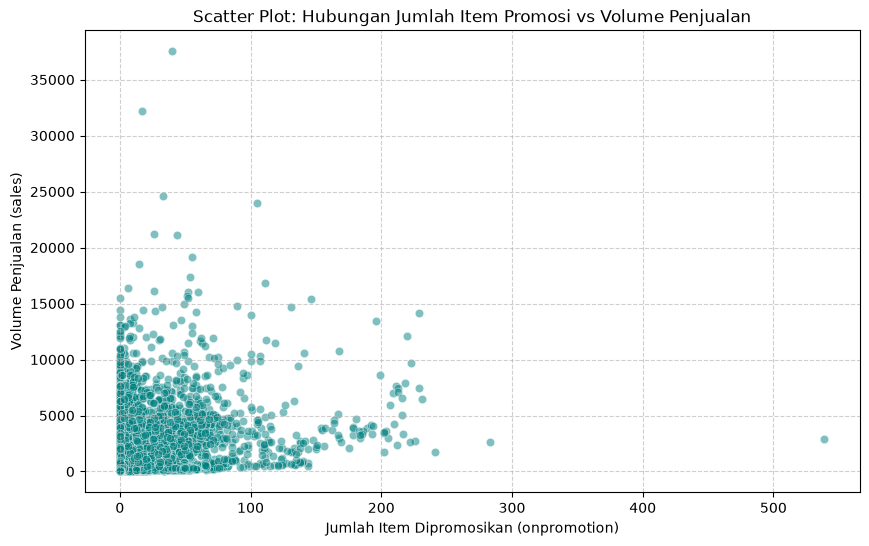

Nilai Korelasi Pearson antara Promosi dan Sales: 0.4279


In [19]:
plt.figure(figsize=(10, 6))
# Menggunakan sampel data (misal 50.000 baris) agar plotting tidak berat/crash
df_sample = df.sample(n=50000, random_state=42)

sns.scatterplot(data=df_sample, x='onpromotion', y='sales', alpha=0.5, color='teal')
plt.title('Scatter Plot: Hubungan Jumlah Item Promosi vs Volume Penjualan')
plt.xlabel('Jumlah Item Dipromosikan (onpromotion)')
plt.ylabel('Volume Penjualan (sales)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Menghitung nilai korelasi Pearson secara numerik
korelasi = df[['onpromotion', 'sales']].corr().iloc[0, 1]
print(f"Nilai Korelasi Pearson antara Promosi dan Sales: {korelasi:.4f}")

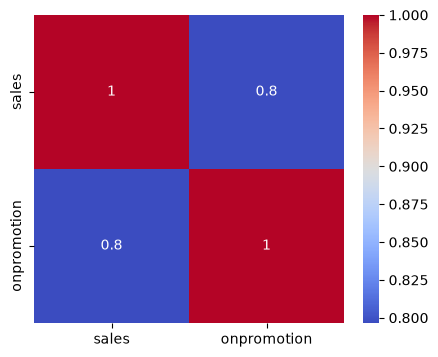

In [20]:
weekly_eda = (
    df
    .resample('W')
    .agg({
        'sales':'sum',
        'onpromotion':'sum'
    })
)

plt.figure(figsize=(5,4))

sns.heatmap(
    weekly_eda.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

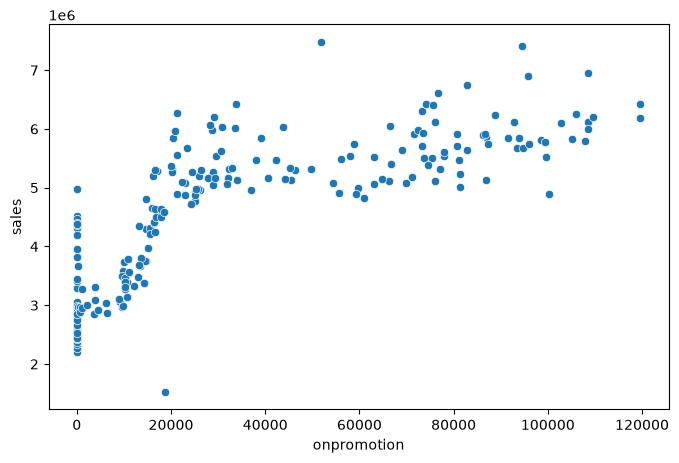

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=weekly_eda,
    x='onpromotion',
    y='sales'
)

plt.show()

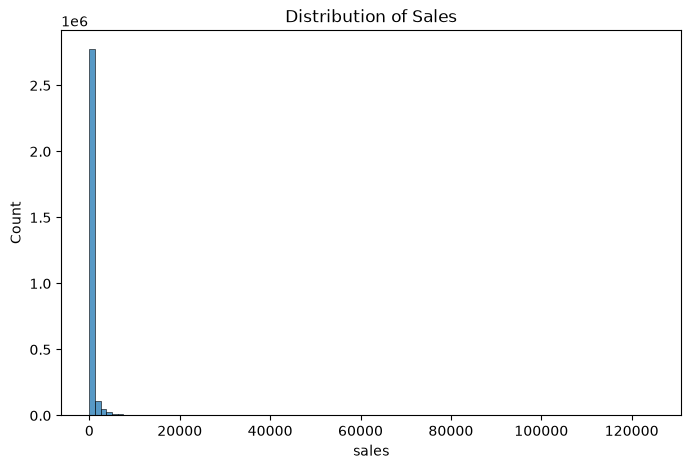

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['sales'], bins=100)
plt.title("Distribution of Sales")
plt.show()

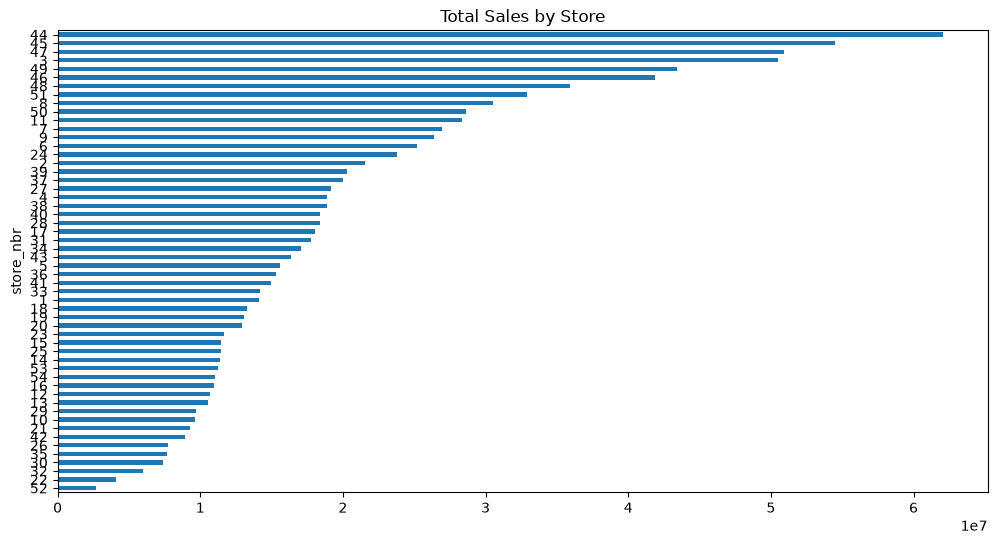

In [23]:
store_sales = (
    df.groupby('store_nbr')['sales']
      .sum()
      .sort_values(ascending=True)
)

plt.figure(figsize=(12,6))
store_sales.plot(kind='barh')
plt.title("Total Sales by Store")
plt.show()

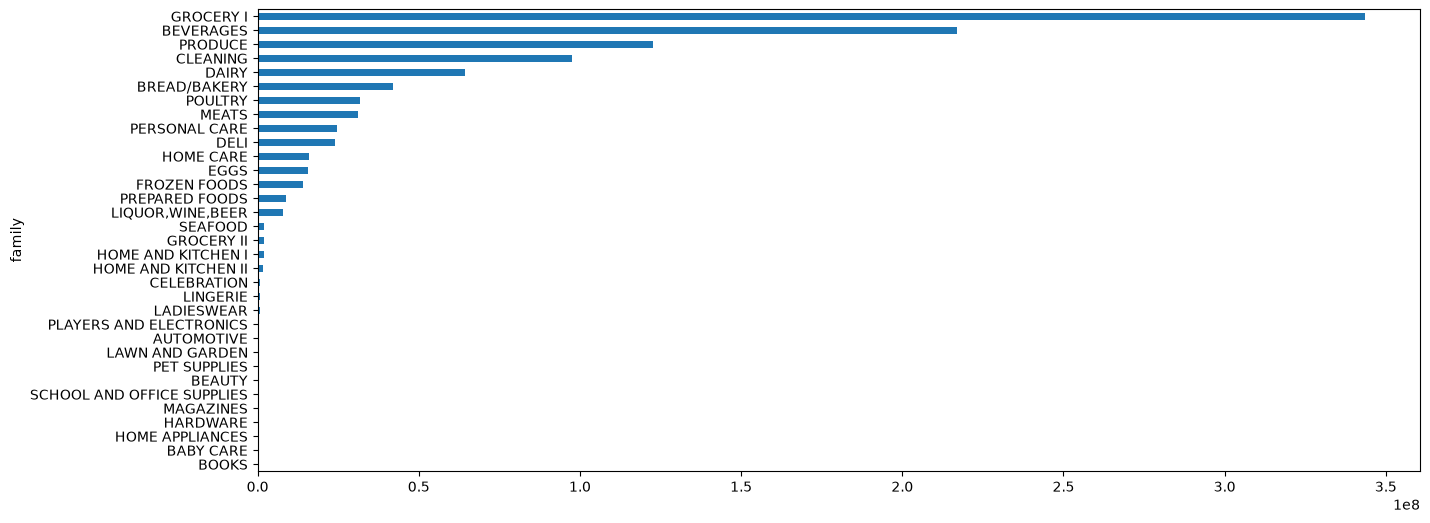

In [24]:
family_sales = (
    df.groupby('family')['sales']
      .sum()
      .sort_values(ascending=True)
)

plt.figure(figsize=(15,6))
family_sales.plot(kind='barh')
plt.show()

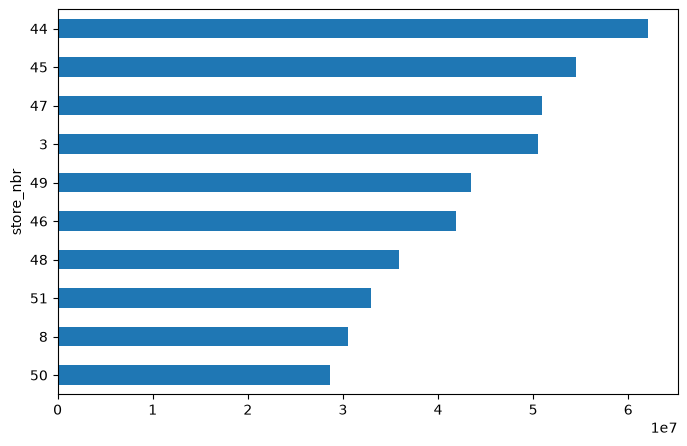

In [25]:
top_store = (
    df.groupby('store_nbr')['sales']
      .sum()
      .nlargest(10).sort_values(ascending=True)
)

plt.figure(figsize=(8,5))
top_store.plot(kind='barh')
plt.show()

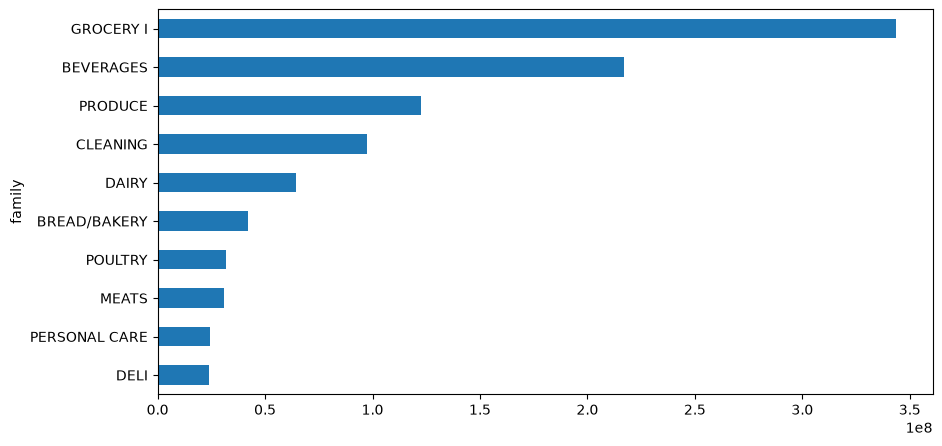

In [26]:
top_family = (
    df.groupby('family')['sales']
      .sum()
      .nlargest(10).sort_values(ascending=True)
)

plt.figure(figsize=(10,5))
top_family.plot(kind='barh')
plt.show()

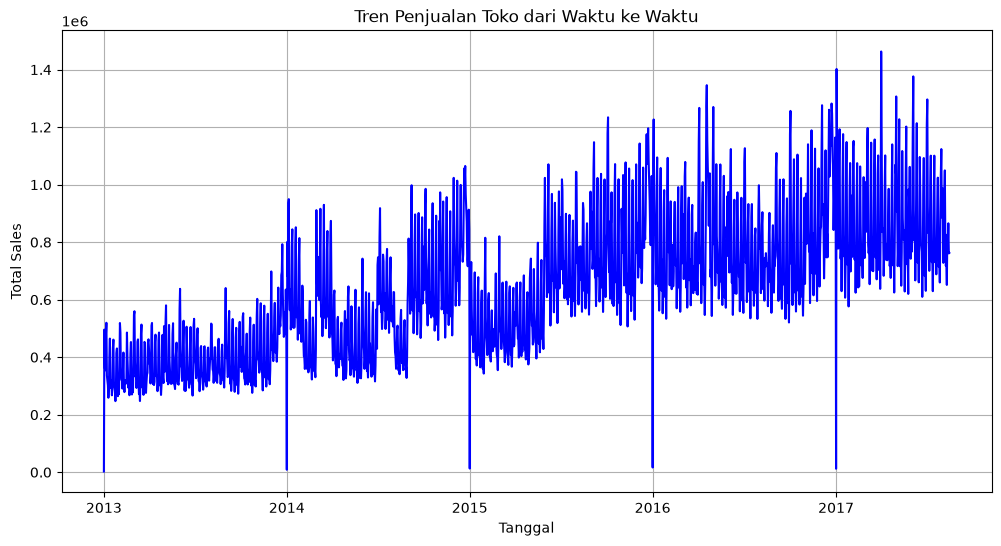

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df_daily.index, df_daily['sales'], label='Total Sales Harian', color='blue')
plt.title('Tren Penjualan Toko dari Waktu ke Waktu')
plt.xlabel('Tanggal')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

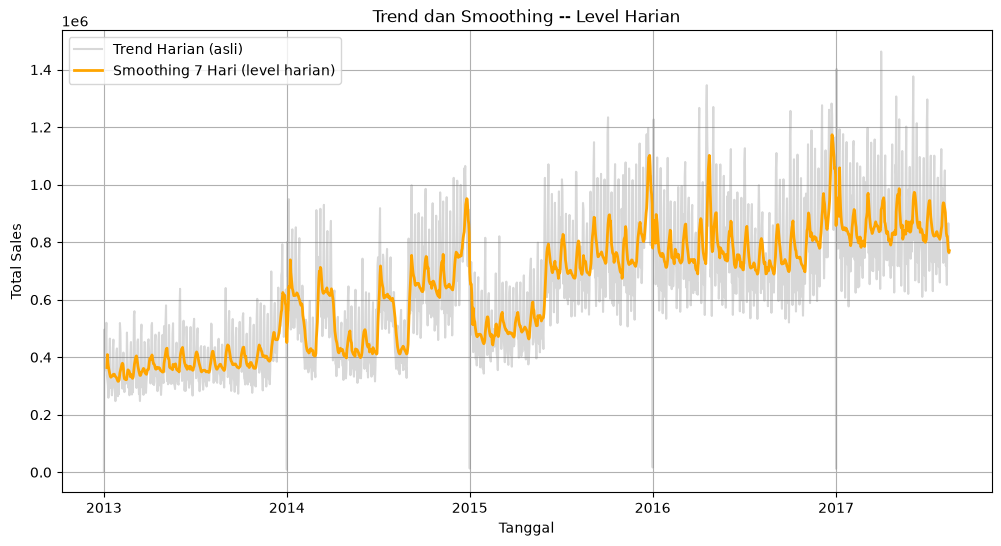

In [28]:
# Smoothing level harian = rolling 7 hari di atas data harian
# (ini meredam noise antar-hari, tetap representasi harian)
df_daily['smoothing_harian_7'] = df_daily['sales'].rolling(window=7).mean()
 
plt.figure(figsize=(12, 6))
plt.plot(df_daily.index, df_daily['sales'], alpha=0.3, label='Trend Harian (asli)', color='gray')
plt.plot(df_daily.index, df_daily['smoothing_harian_7'], label='Smoothing 7 Hari (level harian)', color='orange', linewidth=2)
plt.title('Trend dan Smoothing -- Level Harian')
plt.xlabel('Tanggal')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()

Total baris setelah resample mingguan: 242 minggu
                  sales
date                   
2013-01-06 2,211,570.47
2013-01-13 2,373,617.84
2013-01-20 2,368,007.43
2013-01-27 2,272,164.67
2013-02-03 2,476,890.67


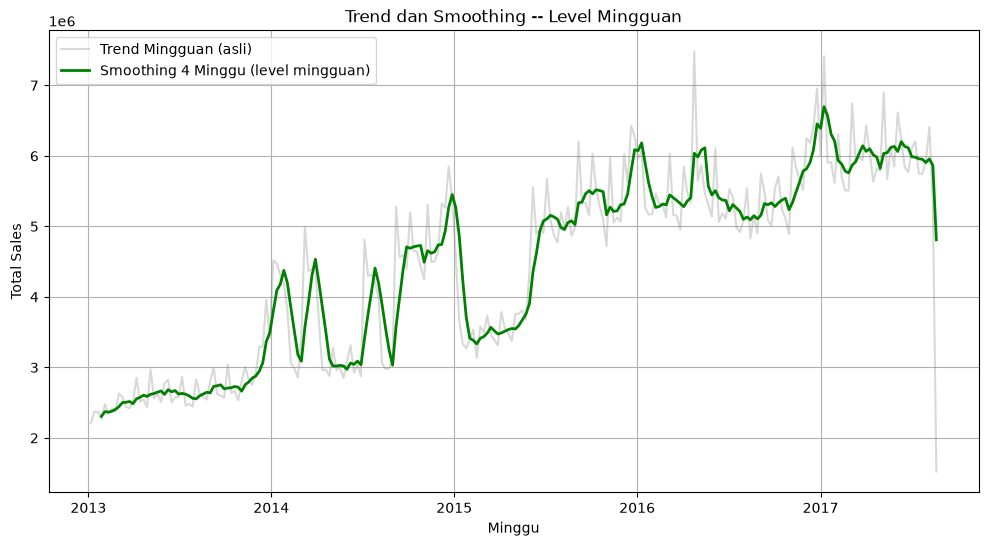

In [ ]:
# -----------------------------------------------------
# LEVEL MINGGUAN
# -----------------------------------------------------
df_weekly = df_daily['sales'].resample('W').sum().to_frame()
df_weekly.columns = ['sales']
 
print(f"Total baris setelah resample mingguan: {len(df_weekly)} minggu")
print(df_weekly.head())
 
# Smoothing level mingguan = rolling mean di atas data MINGGUAN (bukan harian)
# window=4 artinya rata-rata bergerak 4 minggu (kurang lebih 1 bulan)
df_weekly['smoothing_mingguan_4'] = df_weekly['sales'].rolling(window=4).mean()
 
plt.figure(figsize=(12, 6))
plt.plot(df_weekly.index, df_weekly['sales'], alpha=0.3, label='Trend Mingguan (asli)', color='gray')
plt.plot(df_weekly.index, df_weekly['smoothing_mingguan_4'], label='Smoothing 4 Minggu (level mingguan)', color='green', linewidth=2)
plt.title('Trend dan Smoothing -- Level Mingguan')
plt.xlabel('Minggu')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()

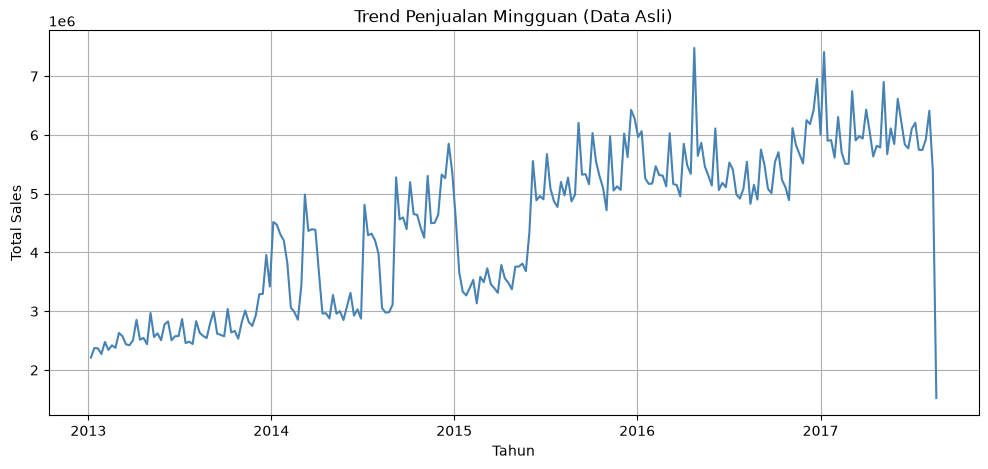

In [71]:
plt.figure(figsize=(12,5))

plt.plot(
    df_weekly.index,
    df_weekly['sales'],
    color='steelblue'
)

plt.title("Trend Penjualan Mingguan (Data Asli)")
plt.xlabel("Tahun")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

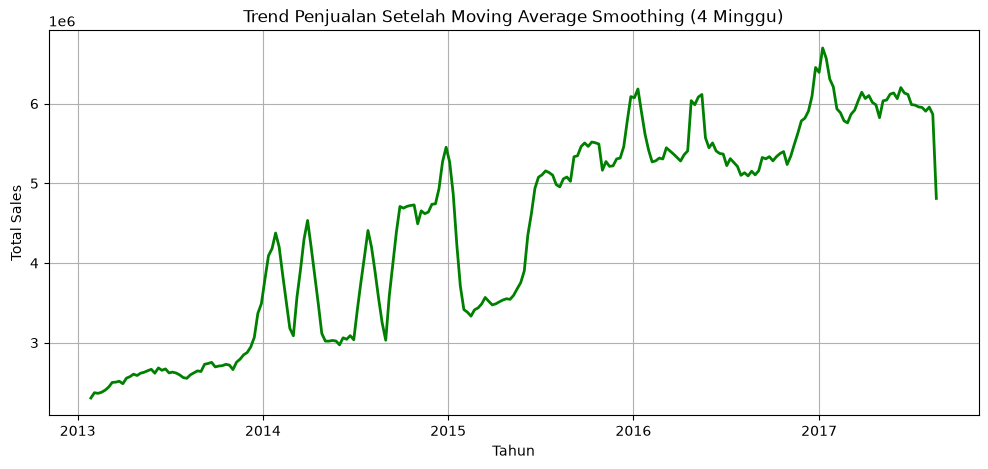

In [72]:
plt.figure(figsize=(12,5))

plt.plot(
    df_weekly.index,
    df_weekly['smoothing_mingguan_4'],
    color='green',
    linewidth=2
)

plt.title("Trend Penjualan Setelah Moving Average Smoothing (4 Minggu)")
plt.xlabel("Tahun")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

Total baris setelah resample bulanan: 56 bulan
                   sales
date                    
2013-01-31 10,327,624.74
2013-02-28  9,658,959.78
2013-03-31 11,428,497.04
2013-04-30 10,993,464.74
2013-05-31 11,597,704.01


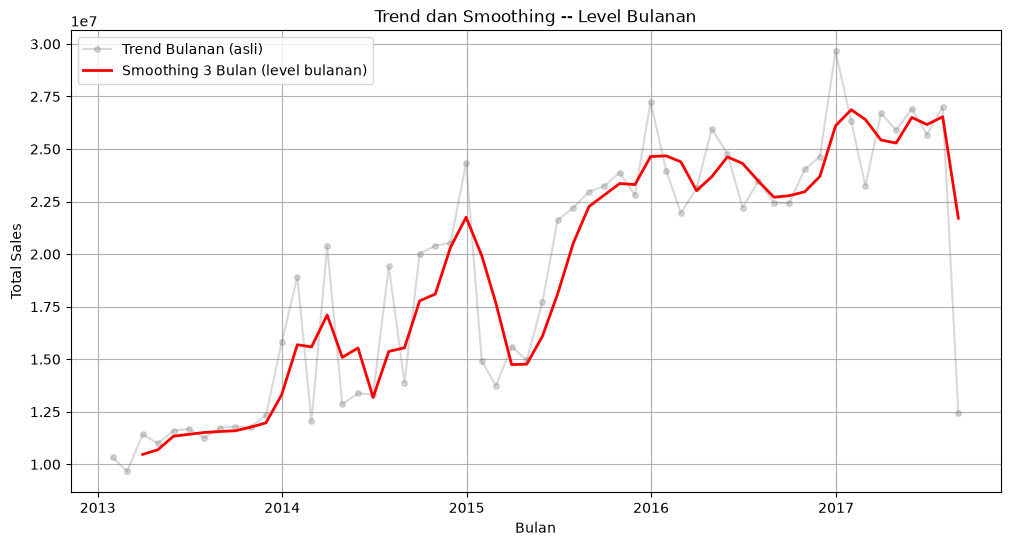

In [30]:
# -----------------------------------------------------
# LEVEL BULANAN
# -----------------------------------------------------
# Resample ke bulanan dulu -- ini yang membuat trend benar-benar di level bulan
df_monthly = df_daily['sales'].resample('ME').sum().to_frame()
df_monthly.columns = ['sales']
 
print(f"Total baris setelah resample bulanan: {len(df_monthly)} bulan")
print(df_monthly.head())
 
# Smoothing level bulanan = rolling mean di atas data BULANAN (bukan harian)
# window=3 artinya rata-rata bergerak 3 bulan (1 kuartal)
df_monthly['smoothing_bulanan_3'] = df_monthly['sales'].rolling(window=3).mean()
 
plt.figure(figsize=(12, 6))
plt.plot(df_monthly.index, df_monthly['sales'], alpha=0.3, label='Trend Bulanan (asli)', color='gray', marker='o', markersize=4)
plt.plot(df_monthly.index, df_monthly['smoothing_bulanan_3'], label='Smoothing 3 Bulan (level bulanan)', color='red', linewidth=2)
plt.title('Trend dan Smoothing -- Level Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()

In [31]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller


### CEK STASIONERITAS DAN ACF/PACF -- LEVEL HARIAN, MINGGUAN

## Harian

In [ ]:
# -----------------------------------------------------
# LEVEL HARIAN
# -----------------------------------------------------

def check_stationarity(series):
    result = adfuller(series.dropna())
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))
        
    # Cara membaca hasilnya:
    if result[1] <= 0.05:
        print("\nKesimpulan: p-value <= 0.05. Data sudah STASIONER.")
    else:
        print("\nKesimpulan: p-value > 0.05. Data TIDAK STASIONER.")

check_stationarity(df_daily['sales'])

ADF Statistic: -2.616196
p-value: 0.089696
Critical Values:
	1%: -3.434
	5%: -2.863
	10%: -2.568

Kesimpulan: p-value > 0.05. Data TIDAK STASIONER.


In [33]:
print()
print("=" * 60)
print("LEVEL HARIAN -- UJI STASIONERITAS (SETELAH DIFFERENCING)")
print("=" * 60)
df_daily['sales_diff'] = df_daily['sales'].diff()
check_stationarity(df_daily['sales_diff'])


LEVEL HARIAN -- UJI STASIONERITAS (SETELAH DIFFERENCING)
ADF Statistic: -11.497600
p-value: 0.000000
Critical Values:
	1%: -3.434
	5%: -2.863
	10%: -2.568

Kesimpulan: p-value <= 0.05. Data sudah STASIONER.


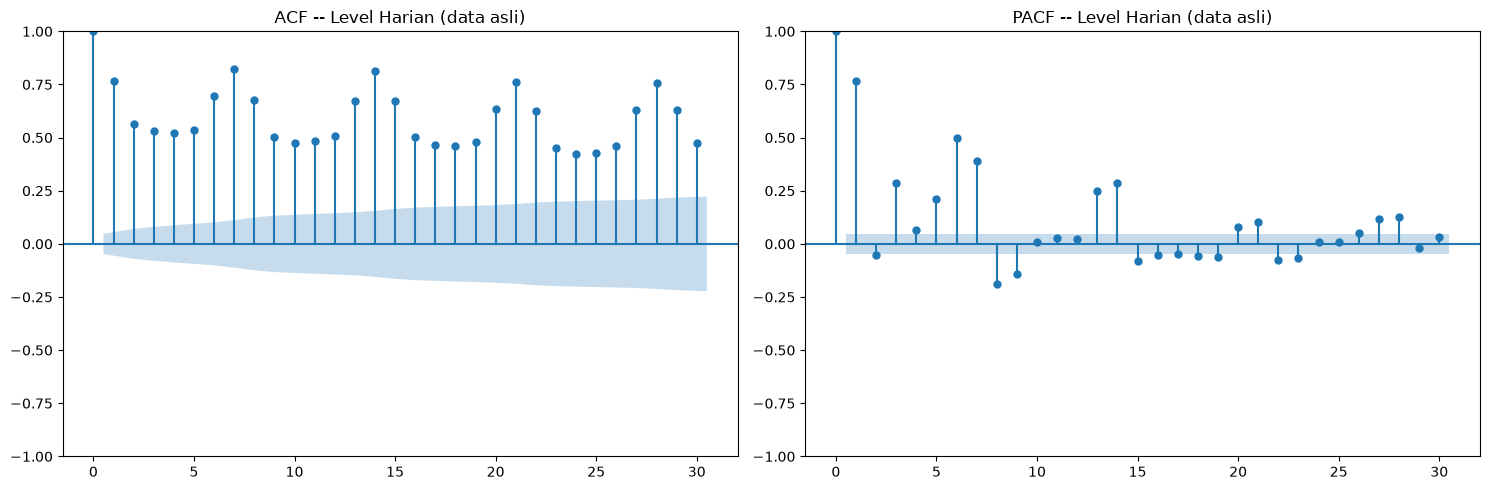

In [34]:
# ACF/PACF level harian -- data asli
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(df_daily['sales'], lags=30, ax=axes[0])
axes[0].set_title('ACF -- Level Harian (data asli)')
plot_pacf(df_daily['sales'], lags=30, ax=axes[1])
axes[1].set_title('PACF -- Level Harian (data asli)')
plt.tight_layout()
plt.show()

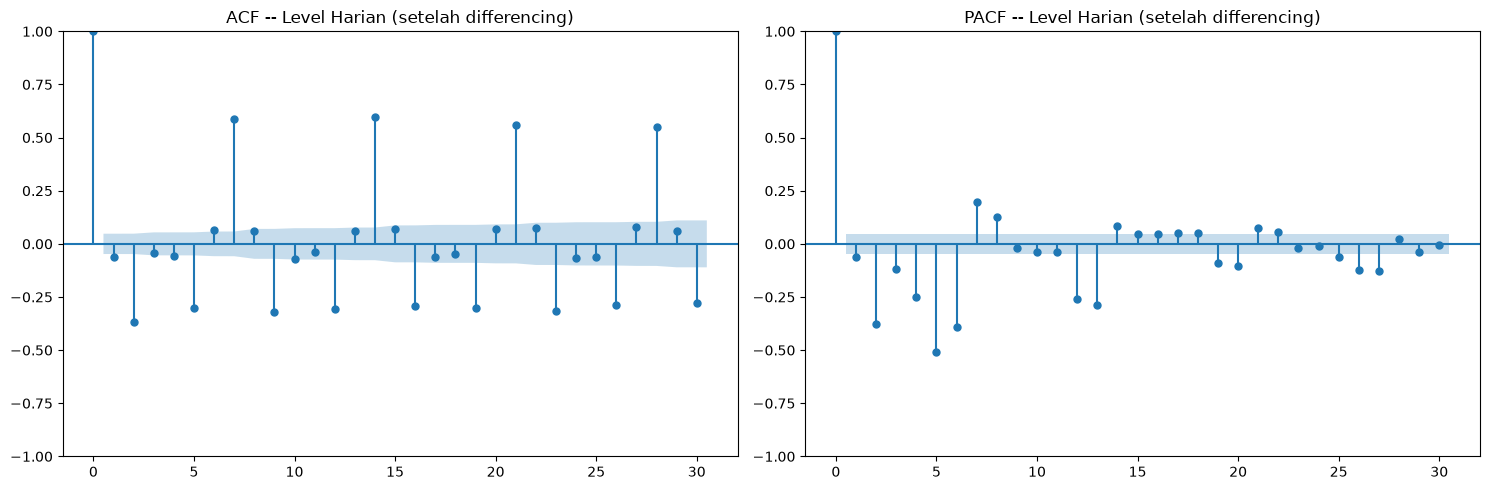

In [35]:
# ACF/PACF level harian -- setelah differencing
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(df_daily['sales_diff'].dropna(), lags=30, ax=axes[0])
axes[0].set_title('ACF -- Level Harian (setelah differencing)')
plot_pacf(df_daily['sales_diff'].dropna(), lags=30, ax=axes[1])
axes[1].set_title('PACF -- Level Harian (setelah differencing)')
plt.tight_layout()
plt.show()

## Mingguan

In [36]:
# -----------------------------------------------------
# LEVEL MINGGUAN
# -----------------------------------------------------
print()
print("=" * 60)
print("LEVEL MINGGUAN -- UJI STASIONERITAS (DATA ASLI)")
print("=" * 60)
check_stationarity(df_weekly['sales'])


LEVEL MINGGUAN -- UJI STASIONERITAS (DATA ASLI)
ADF Statistic: -1.913783
p-value: 0.325605
Critical Values:
	1%: -3.459
	5%: -2.874
	10%: -2.573

Kesimpulan: p-value > 0.05. Data TIDAK STASIONER.


In [37]:
print()
print("=" * 60)
print("LEVEL MINGGUAN -- UJI STASIONERITAS (SETELAH DIFFERENCING)")
print("=" * 60)
df_weekly['sales_diff'] = df_weekly['sales'].diff()
check_stationarity(df_weekly['sales_diff'])


LEVEL MINGGUAN -- UJI STASIONERITAS (SETELAH DIFFERENCING)
ADF Statistic: -4.765766
p-value: 0.000063
Critical Values:
	1%: -3.459
	5%: -2.874
	10%: -2.573

Kesimpulan: p-value <= 0.05. Data sudah STASIONER.


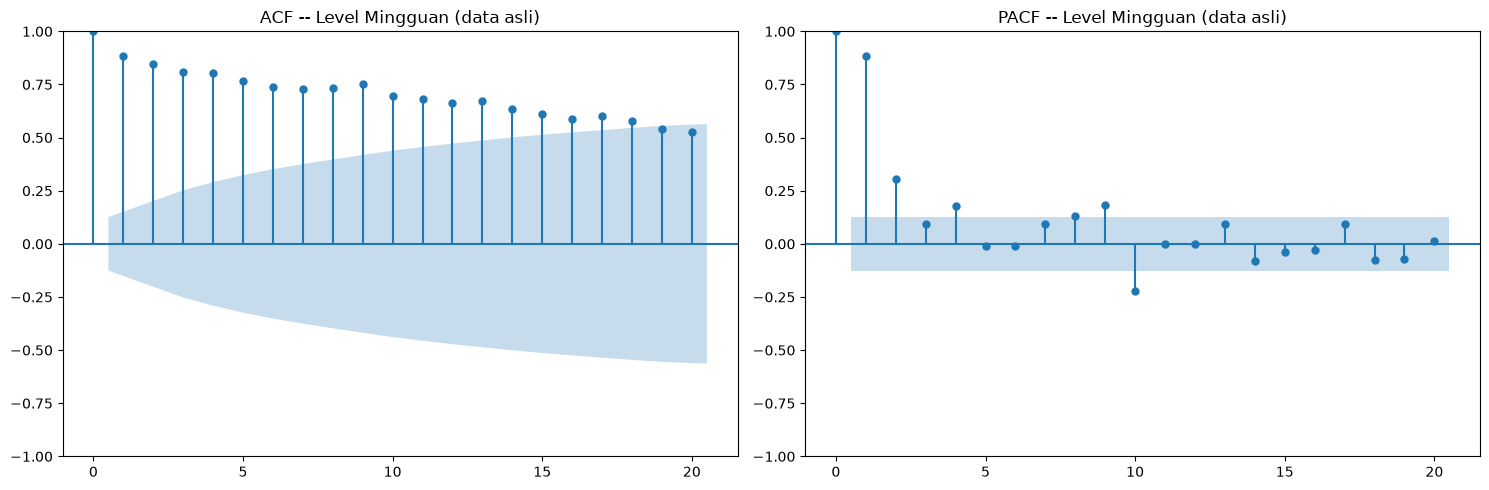

In [38]:
# ACF/PACF level mingguan -- data asli
# Catatan: lags dikecilkan ke 20 karena jumlah baris mingguan jauh lebih sedikit
# dibanding harian (sekitar 200-an minggu vs ribuan hari)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(df_weekly['sales'], lags=20, ax=axes[0])
axes[0].set_title('ACF -- Level Mingguan (data asli)')
plot_pacf(df_weekly['sales'], lags=20, ax=axes[1])
axes[1].set_title('PACF -- Level Mingguan (data asli)')
plt.tight_layout()
plt.show()

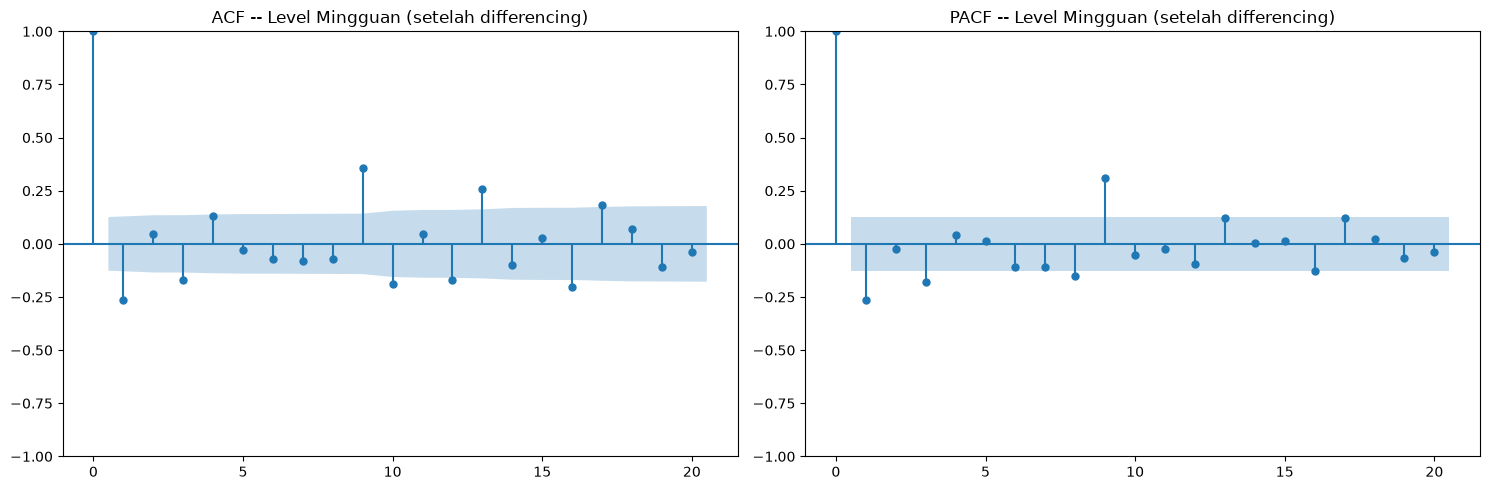

In [39]:
# ACF/PACF level mingguan -- setelah differencing
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(df_weekly['sales_diff'].dropna(), lags=20, ax=axes[0])
axes[0].set_title('ACF -- Level Mingguan (setelah differencing)')
plot_pacf(df_weekly['sales_diff'].dropna(), lags=20, ax=axes[1])
axes[1].set_title('PACF -- Level Mingguan (setelah differencing)')
plt.tight_layout()
plt.show()

## Train-Test Split

In [ ]:
# =========================================================
# CEK KELENGKAPAN DATA DI AKHIR PERIODE -- LEVEL MINGGUAN
# =========================================================
print("Tanggal terakhir di data mingguan:", df_weekly.index.max())
print()
print("5 baris terakhir df_weekly (cek apakah ada penurunan tajam):")
print(df_weekly['sales'].tail(5))
print()

# Cek jumlah hari asli yang masuk ke minggu terakhir:
hari_di_minggu_terakhir = df_daily.loc[
    df_daily.index >= (df_weekly.index[-1] - pd.Timedelta(days=6))
]
print(f"Jumlah hari yang masuk ke minggu terakhir: {len(hari_di_minggu_terakhir)} hari")
print("(idealnya 7 hari -- kalau kurang, minggu ini tidak lengkap)")

Tanggal terakhir di data mingguan: 2017-08-20 00:00:00

5 baris terakhir df_weekly (cek apakah ada penurunan tajam):
date
2017-07-23   5,744,335.16
2017-07-30   5,921,811.86
2017-08-06   6,410,193.61
2017-08-13   5,385,401.83
2017-08-20   1,523,584.34
Freq: W-SUN, Name: sales, dtype: float64

Jumlah hari yang masuk ke minggu terakhir: 2 hari
(idealnya 7 hari -- kalau kurang, minggu ini tidak lengkap)


In [42]:
# =========================================================
# EXCLUDE MINGGU TERAKHIR YANG TIDAK LENGKAP
# =========================================================
N_EXCLUDE_MINGGUAN = 1  # sesuaikan berdasarkan hasil cek di atas

df_weekly_clean = df_weekly.iloc[:-N_EXCLUDE_MINGGUAN].copy()

print(f"Data sebelum exclude: {len(df_weekly)} minggu")
print(f"Data setelah exclude: {len(df_weekly_clean)} minggu")
print(f"Periode final: {df_weekly_clean.index.min()} s/d {df_weekly_clean.index.max()}")

Data sebelum exclude: 242 minggu
Data setelah exclude: 241 minggu
Periode final: 2013-01-06 00:00:00 s/d 2017-08-13 00:00:00


HASIL SPLIT 80:20 -- LEVEL MINGGUAN
Total data       : 241 minggu
Data train (80%) : 192 minggu  |  2013-01-06 s/d 2016-09-04
Data test  (20%) : 49 minggu  |  2016-09-11 s/d 2017-08-13



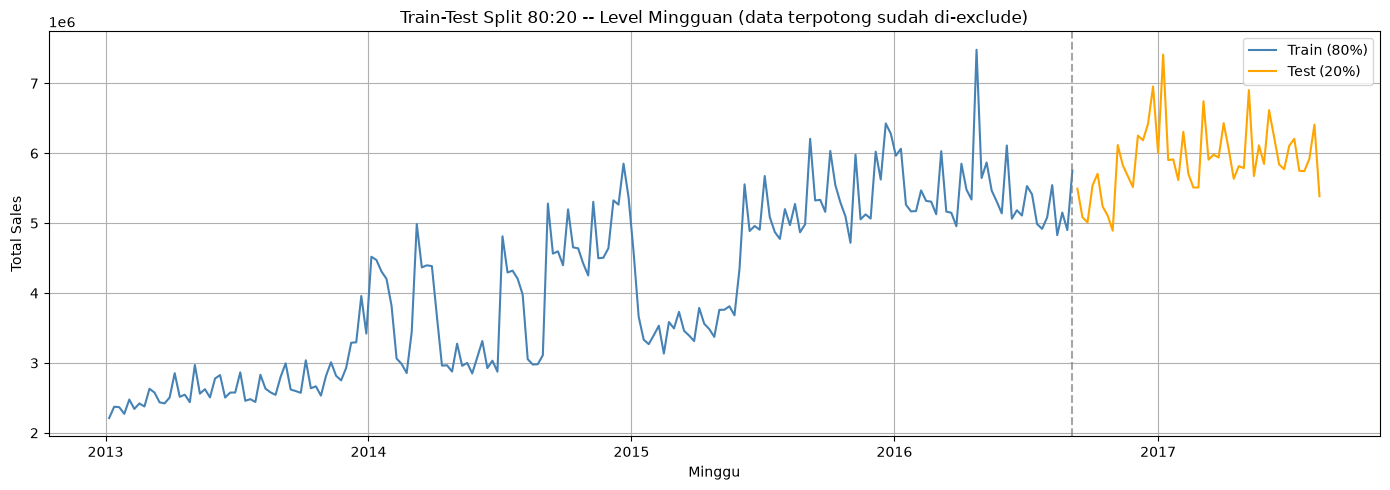

In [43]:
# =========================================================
# TRAIN-TEST SPLIT -- 80:20, KRONOLOGIS (BUKAN ACAK)
# =========================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

n_total = len(df_weekly_clean)
n_train = int(n_total * 0.8)
n_test = n_total - n_train

train_weekly = df_weekly_clean['sales'].iloc[:n_train]
test_weekly = df_weekly_clean['sales'].iloc[n_train:]

print("=" * 60)
print("HASIL SPLIT 80:20 -- LEVEL MINGGUAN")
print("=" * 60)
print(f"Total data       : {n_total} minggu")
print(f"Data train (80%) : {len(train_weekly)} minggu  |  {train_weekly.index.min().date()} s/d {train_weekly.index.max().date()}")
print(f"Data test  (20%) : {len(test_weekly)} minggu  |  {test_weekly.index.min().date()} s/d {test_weekly.index.max().date()}")
print()

# Visualisasi hasil split
plt.figure(figsize=(14, 5))
plt.plot(train_weekly.index, train_weekly, label='Train (80%)', color='steelblue')
plt.plot(test_weekly.index, test_weekly, label='Test (20%)', color='orange')
plt.axvline(x=train_weekly.index[-1], color='gray', linestyle='--', alpha=0.7)
plt.title('Train-Test Split 80:20 -- Level Mingguan (data terpotong sudah di-exclude)')
plt.xlabel('Minggu')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

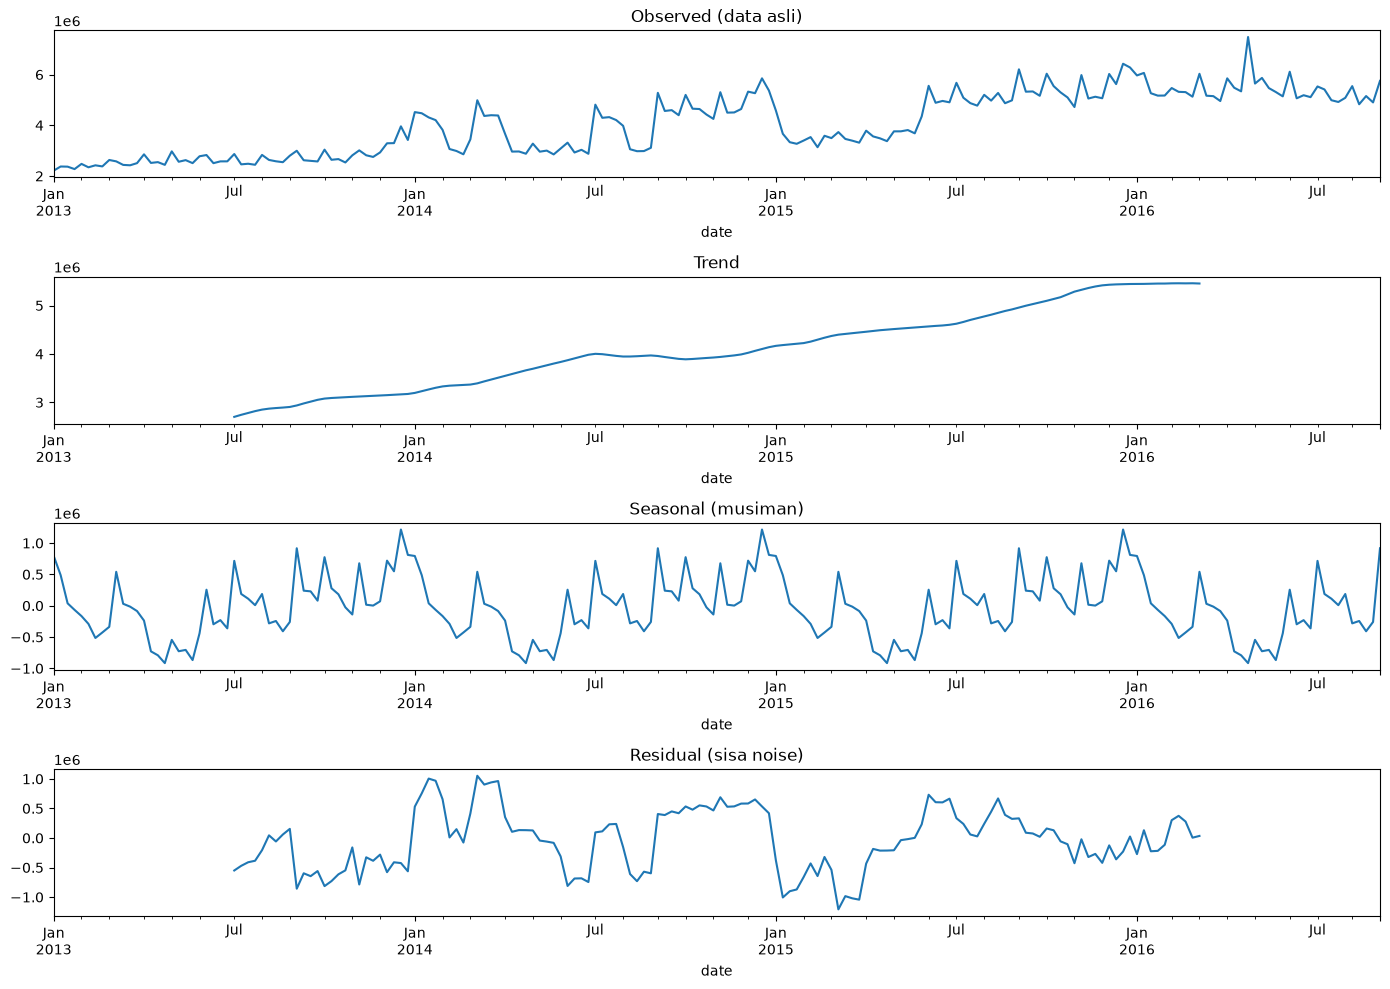

CARA BACA:
- Kalau panel 'Seasonal' menunjukkan pola berulang yang JELAS
  dan amplitudonya cukup besar (tidak mendekati nol), berarti
  m=52 cocok dan musiman tahunan memang ada di data kamu.
- Kalau panel Seasonal terlihat datar/acak, coba period lain,
  misal 4 (musiman bulanan) atau cek lagi apakah benar2 ada musiman.


In [44]:
# =========================================================
# IDENTIFIKASI MUSIMAN -- SEASONAL DECOMPOSE
# =========================================================
from statsmodels.tsa.seasonal import seasonal_decompose

# period harus diisi asumsi awal -- coba 52 dulu (musiman tahunan)
# kalau data train kamu minimal 2x52 minggu (~2 tahun), ini valid dijalankan
decomposition = seasonal_decompose(train_weekly, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Observed (data asli)')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal (musiman)')
decomposition.resid.plot(ax=axes[3], title='Residual (sisa noise)')
plt.tight_layout()
plt.show()

print("CARA BACA:")
print("- Kalau panel 'Seasonal' menunjukkan pola berulang yang JELAS")
print("  dan amplitudonya cukup besar (tidak mendekati nol), berarti")
print("  m=52 cocok dan musiman tahunan memang ada di data kamu.")
print("- Kalau panel Seasonal terlihat datar/acak, coba period lain,")
print("  misal 4 (musiman bulanan) atau cek lagi apakah benar2 ada musiman.")

In [45]:
# =========================================================
# FUNGSI EVALUASI -- DIPAKAI UNTUK SEMUA METODE
# =========================================================
def evaluasi_model(y_true, y_pred, nama_model=''):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    print(f"--- Evaluasi: {nama_model} ---")
    print(f"RMSE : {rmse:,.2f}")
    print(f"MAE  : {mae:,.2f}")
    print(f"MAPE : {mape:.2f}%")
    print()

    return {'model': nama_model, 'rmse': rmse, 'mae': mae, 'mape': mape}

# List penampung hasil semua model -- akan terus ditambah
hasil_semua_model = []

In [46]:
# =========================================================
# BASELINE -- NAIVE FORECAST
# =========================================================
naive_pred = np.repeat(train_weekly.iloc[-1], len(test_weekly))
hasil_naive = evaluasi_model(test_weekly.values, naive_pred, 'Naive Baseline')
hasil_semua_model.append(hasil_naive)

--- Evaluasi: Naive Baseline ---
RMSE : 523,645.65
MAE  : 385,162.65
MAPE : 6.34%



                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  192
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2777.251
Date:                Wed, 01 Jul 2026   AIC                           5560.502
Time:                        10:29:00   BIC                           5570.258
Sample:                    01-06-2013   HQIC                          5564.453
                         - 09-04-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4650      0.124      3.756      0.000       0.222       0.708
ma.L1         -0.7886      0.098     -8.035      0.000      -0.981      -0.596
sigma2      2.561e+11   1.22e-13   2.11e+24      0.0

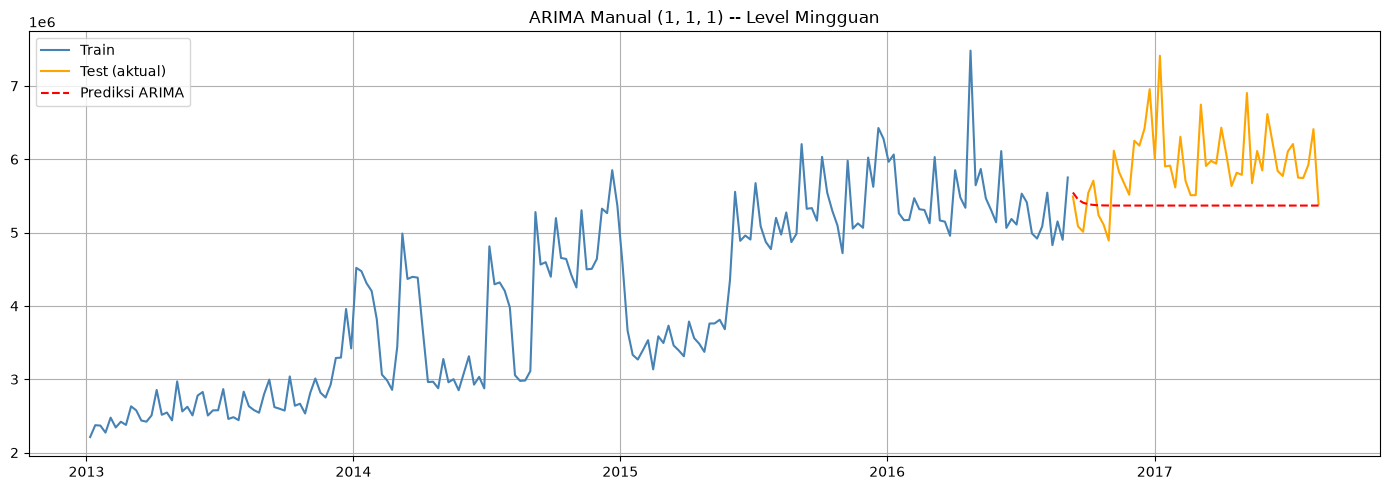

In [47]:
# =========================================================
# ARIMA MANUAL -- LEVEL MINGGUAN
# =========================================================
# Ganti order=(p,d,q) sesuai pembacaan ACF/PACF kamu sebelumnya.
# d=1 karena dari uji stasioneritas, data asli belum stasioner
# tapi setelah 1x differencing biasanya sudah stasioner.

from statsmodels.tsa.arima.model import ARIMA

order_manual = (1, 1, 1)  # SESUAIKAN dengan hasil baca ACF/PACF kamu

model_arima = ARIMA(train_weekly, order=order_manual)
model_arima_fit = model_arima.fit()
print(model_arima_fit.summary())

pred_arima = model_arima_fit.forecast(steps=len(test_weekly))
hasil_arima = evaluasi_model(test_weekly.values, pred_arima.values, f'ARIMA Manual {order_manual}')
hasil_semua_model.append(hasil_arima)

# Plot perbandingan aktual vs prediksi
plt.figure(figsize=(14, 5))
plt.plot(train_weekly.index, train_weekly, label='Train', color='steelblue')
plt.plot(test_weekly.index, test_weekly, label='Test (aktual)', color='orange')
plt.plot(test_weekly.index, pred_arima, label='Prediksi ARIMA', color='red', linestyle='--')
plt.title(f'ARIMA Manual {order_manual} -- Level Mingguan')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[52] intercept   : AIC=5546.651, Time=2.16 sec
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=5581.660, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=5542.109, Time=0.52 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=5544.497, Time=0.78 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=5579.895, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=5564.401, Time=0.03 sec
 ARIMA(1,1,0)(2,0,0)[52] intercept   : AIC=5544.105, Time=3.10 sec
 ARIMA(1,1,0)(1,0,1)[52] intercept   : AIC=5544.097, Time=0.86 sec
 ARIMA(1,1,0)(0,0,1)[52] intercept   : AIC=5543.937, Time=0.66 sec
 ARIMA(1,1,0)(2,0,1)[52] intercept   : AIC=inf, Time=11.62 sec
 ARIMA(0,1,0)(1,0,0)[52] intercept   : AIC=5555.430, Time=0.31 sec
 ARIMA(2,1,0)(1,0,0)[52] intercept   : AIC=5544.223, Time=0.50 sec
 ARIMA(1,1,1)(1,0,0)[52] intercept   : AIC=5544.441, Time=0.69 sec
 ARIMA(0,1,1)(1,0,0)[52] intercept   : AIC=5543.228, Time=0.35 sec
 ARIMA(2,1,1)(1,0,0)[52

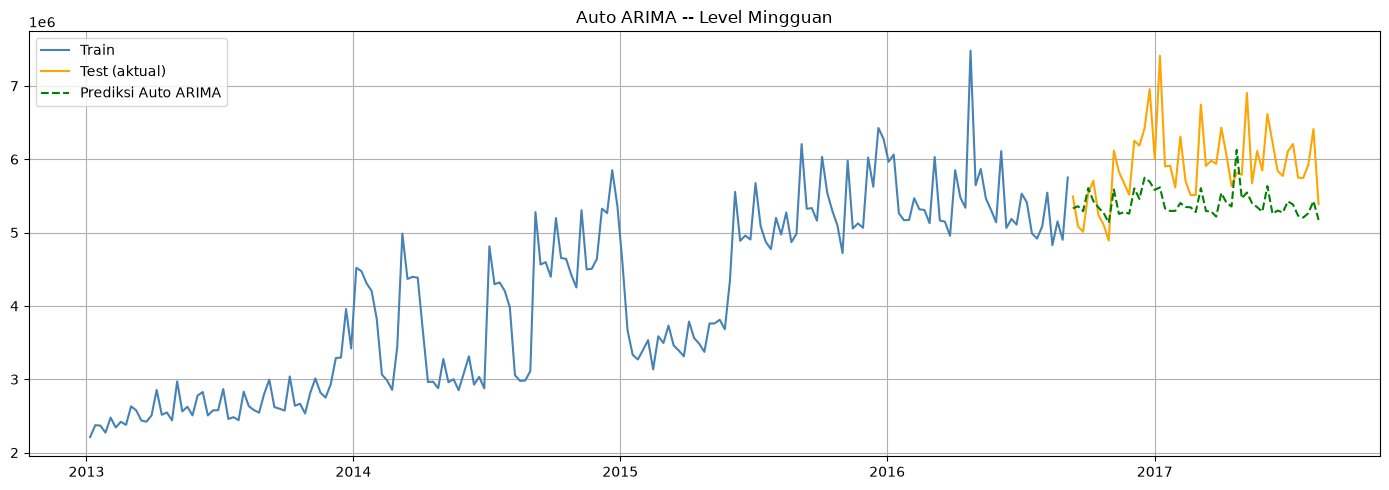

In [48]:
# =========================================================
# AUTO ARIMA -- LEVEL MINGGUAN
# =========================================================
from pmdarima import auto_arima

model_auto = auto_arima(
    train_weekly,
    seasonal=True,
    m=52,              
    d=1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
print(model_auto.summary())

pred_auto = model_auto.predict(n_periods=len(test_weekly))
hasil_auto = evaluasi_model(test_weekly.values, pred_auto, 'Auto ARIMA')
hasil_semua_model.append(hasil_auto)

plt.figure(figsize=(14, 5))
plt.plot(train_weekly.index, train_weekly, label='Train', color='steelblue')
plt.plot(test_weekly.index, test_weekly, label='Test (aktual)', color='orange')
plt.plot(test_weekly.index, pred_auto, label='Prediksi Auto ARIMA', color='green', linestyle='--')
plt.title('Auto ARIMA -- Level Mingguan')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                  192
Model:             SARIMAX(1, 1, 0)x(1, 0, 0, 52)   Log Likelihood               -2012.807
Date:                            Wed, 01 Jul 2026   AIC                           4031.614
Time:                                    10:29:41   BIC                           4040.395
Sample:                                01-06-2013   HQIC                          4035.182
                                     - 09-04-2016                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2467      0.061     -4.071      0.000      -0.366      -0.128
ar.S.L52       0.4787      0.093   

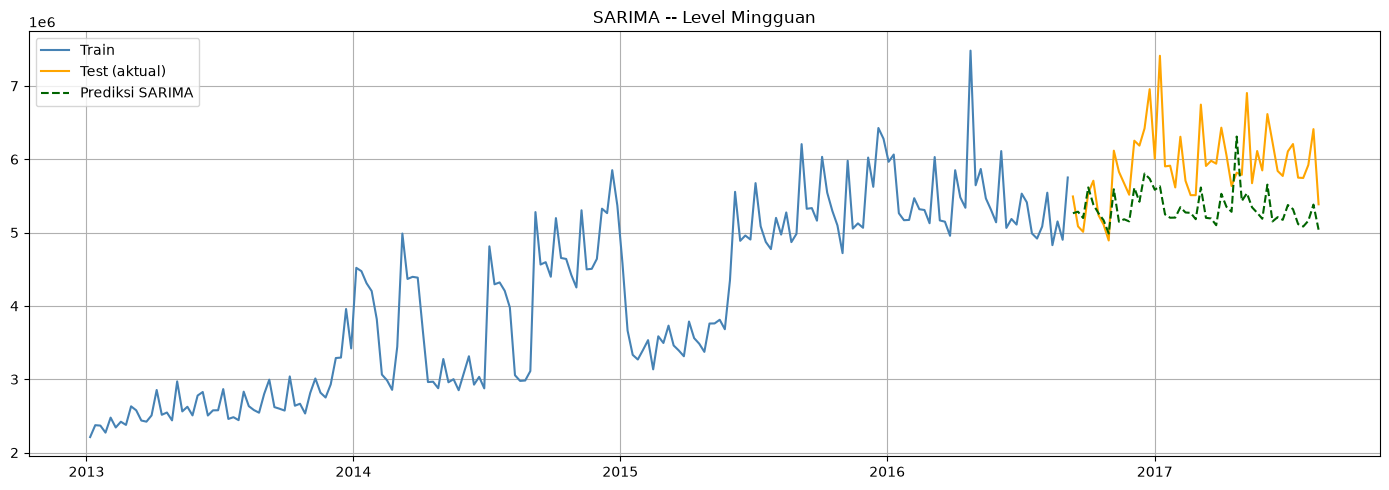

In [49]:
# =========================================================
# SARIMA -- LEVEL MINGGUAN (ARIMA + komponen musiman)
# =========================================================
from statsmodels.tsa.statespace.sarimax import SARIMAX

# order = (p,d,q) non-musiman, seasonal_order = (P,D,Q,m) musiman
# m=52 karena data mingguan, siklus musiman tahunan = 52 minggu
order_sarima = (1, 1, 0)
seasonal_order_sarima = (1, 0, 0, 52)

model_sarima = SARIMAX(
    train_weekly,
    order=order_sarima,
    seasonal_order=seasonal_order_sarima,
    enforce_stationarity=False,
    enforce_invertibility=False
)
model_sarima_fit = model_sarima.fit(disp=False)
print(model_sarima_fit.summary())

pred_sarima = model_sarima_fit.forecast(steps=len(test_weekly))
hasil_sarima = evaluasi_model(test_weekly.values, pred_sarima.values, f'SARIMA {order_sarima}x{seasonal_order_sarima}')
hasil_semua_model.append(hasil_sarima)

plt.figure(figsize=(14, 5))
plt.plot(train_weekly.index, train_weekly, label='Train', color='steelblue')
plt.plot(test_weekly.index, test_weekly, label='Test (aktual)', color='orange')
plt.plot(test_weekly.index, pred_sarima, label='Prediksi SARIMA', color='darkgreen', linestyle='--')
plt.title('SARIMA -- Level Mingguan')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [50]:
# =========================================================
# AGREGASI onpromotion KE LEVEL MINGGUAN -- DARI df ASLI
# =========================================================

# Buat salinan khusus untuk agregasi promosi, supaya tidak mengubah df asli
df_promo = df.copy()

# Resample ke mingguan -- W berarti akhir minggu (Minggu), sama seperti df_weekly
promo_weekly = df_promo['onpromotion'].resample('W').sum()

print(f"Jumlah baris promo_weekly: {len(promo_weekly)} minggu")
print(promo_weekly.head())
print()

# Selaraskan index dengan df_weekly_clean yang sudah di-exclude minggu terpotongnya
promo_weekly_clean = promo_weekly.loc[df_weekly_clean.index]

print(f"Setelah diselaraskan dengan df_weekly_clean: {len(promo_weekly_clean)} minggu")
print("Cek index sama persis:", (promo_weekly_clean.index == df_weekly_clean.index).all())

Jumlah baris promo_weekly: 242 minggu
date
2013-01-06    0
2013-01-13    0
2013-01-20    0
2013-01-27    0
2013-02-03    0
Freq: W-SUN, Name: onpromotion, dtype: int64

Setelah diselaraskan dengan df_weekly_clean: 241 minggu
Cek index sama persis: True


In [51]:
# =========================================================
# SPLIT EXOGENOUS -- MENGIKUTI SPLIT SALES YANG SUDAH ADA
# =========================================================
exog_train = promo_weekly_clean.iloc[:n_train]
exog_test = promo_weekly_clean.iloc[n_train:]

print(f"exog_train: {len(exog_train)} minggu, periode {exog_train.index.min()} s/d {exog_train.index.max()}")
print(f"exog_test : {len(exog_test)} minggu, periode {exog_test.index.min()} s/d {exog_test.index.max()}")
print()

# Pastikan jumlahnya sama persis dengan train_weekly/test_weekly
assert len(exog_train) == len(train_weekly), "Jumlah exog_train tidak sama dengan train_weekly!"
assert len(exog_test) == len(test_weekly), "Jumlah exog_test tidak sama dengan test_weekly!"
print("Validasi OK -- panjang exog dan sales sudah selaras.")

exog_train: 192 minggu, periode 2013-01-06 00:00:00 s/d 2016-09-04 00:00:00
exog_test : 49 minggu, periode 2016-09-11 00:00:00 s/d 2017-08-13 00:00:00

Validasi OK -- panjang exog dan sales sudah selaras.


Cek korelasi sederhana sales vs onpromotion (eksplorasi awal):
             sales  onpromotion
sales         1.00         0.76
onpromotion   0.76         1.00

                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                  192
Model:             SARIMAX(1, 1, 0)x(1, 0, 0, 52)   Log Likelihood               -2010.644
Date:                            Wed, 01 Jul 2026   AIC                           4029.288
Time:                                    10:29:43   BIC                           4040.997
Sample:                                01-06-2013   HQIC                          4034.047
                                     - 09-04-2016                                         
Covariance Type:                              opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------

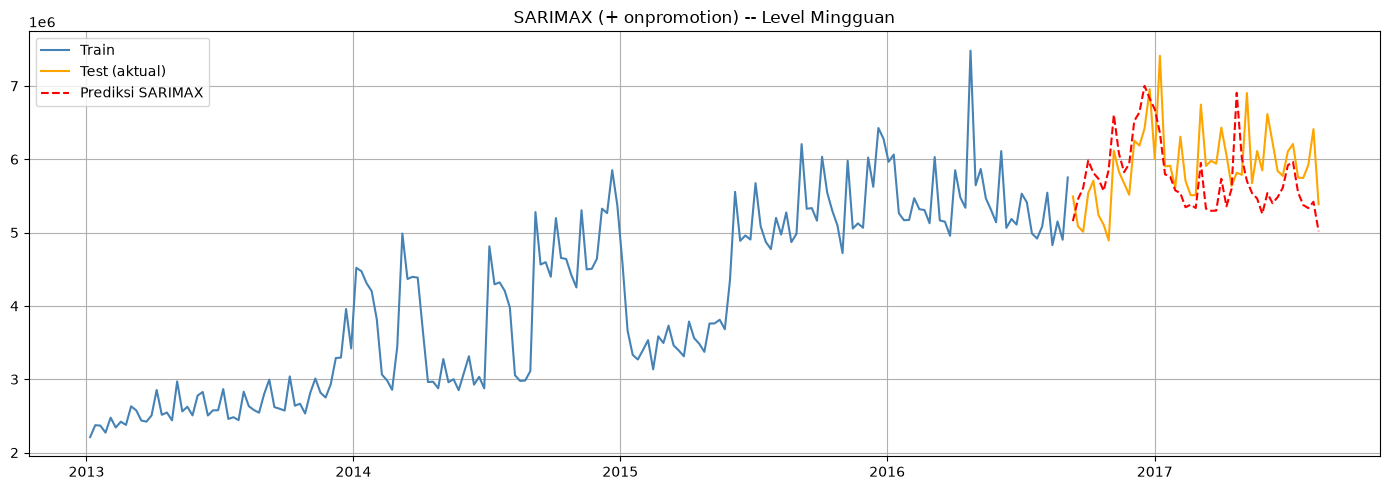

In [52]:
# =========================================================
# SARIMAX -- LEVEL MINGGUAN (SARIMA + onpromotion sebagai exogenous)
# =========================================================

# promo_weekly = df.groupby(pd.Grouper(key='date', freq='W'))['onpromotion'].sum()
# promo_weekly = promo_weekly.loc[df_weekly_clean.index]  # selaraskan index dengan data sales yang sudah dibersihkan

# # Split exogenous mengikuti split train-test sales
# exog_train = promo_weekly.iloc[:n_train]
# exog_test = promo_weekly.iloc[n_train:]

print("Cek korelasi sederhana sales vs onpromotion (eksplorasi awal):")
print(pd.DataFrame({'sales': train_weekly, 'onpromotion': exog_train}).corr())
print()

model_sarimax = SARIMAX(
    train_weekly,
    exog=exog_train,
    order=order_sarima,
    seasonal_order=seasonal_order_sarima,
    enforce_stationarity=False,
    enforce_invertibility=False
)
model_sarimax_fit = model_sarimax.fit(disp=False)
print(model_sarimax_fit.summary())
print()
print("PERHATIKAN baris 'onpromotion' di tabel coef di atas:")
print("- coef positif & p-value < 0.05 -> promosi signifikan menaikkan sales")
print("- coef negatif/tidak signifikan -> promosi tidak terbukti berpengaruh")
print()

pred_sarimax = model_sarimax_fit.forecast(steps=len(test_weekly), exog=exog_test)
hasil_sarimax = evaluasi_model(test_weekly.values, pred_sarimax.values, 'SARIMAX (+ onpromotion)')
hasil_semua_model.append(hasil_sarimax)

plt.figure(figsize=(14, 5))
plt.plot(train_weekly.index, train_weekly, label='Train', color='steelblue')
plt.plot(test_weekly.index, test_weekly, label='Test (aktual)', color='orange')
plt.plot(test_weekly.index, pred_sarimax, label='Prediksi SARIMAX', color='red', linestyle='--')
plt.title('SARIMAX (+ onpromotion) -- Level Mingguan')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

d:\irvan\apps\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
10:29:44 - cmdstanpy - INFO - Chain [1] start processing
10:29:44 - cmdstanpy - INFO - Chain [1] done processing


--- Evaluasi: Prophet ---
RMSE : 645,780.27
MAE  : 566,804.48
MAPE : 9.92%



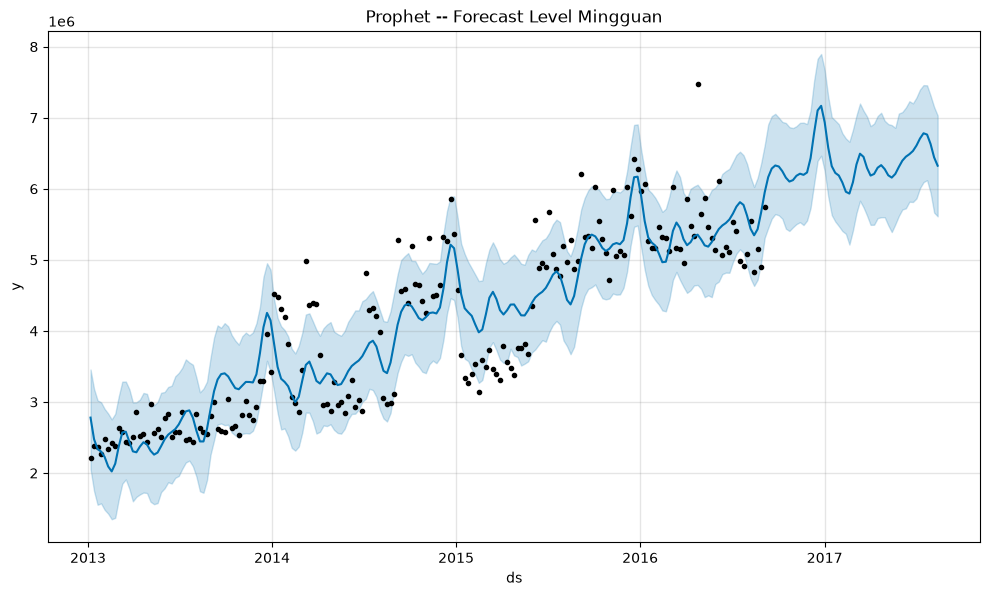

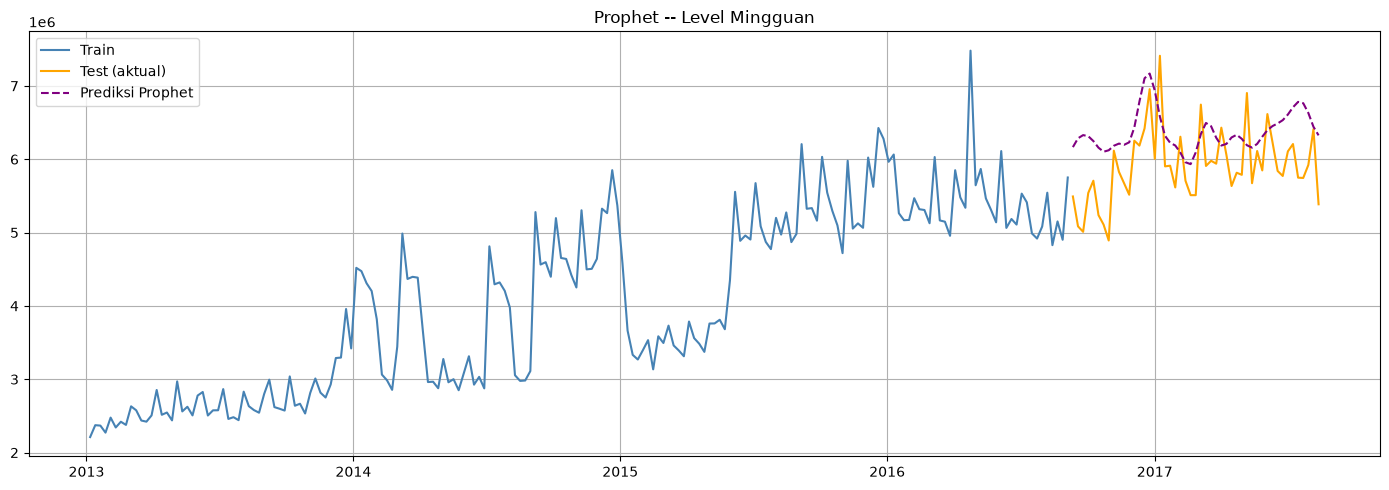

In [53]:
# =========================================================
# PROPHET -- LEVEL MINGGUAN
# =========================================================
from prophet import Prophet

# Prophet butuh format kolom khusus: 'ds' (tanggal) dan 'y' (nilai)
df_prophet_train = train_weekly.reset_index()
df_prophet_train.columns = ['ds', 'y']

model_prophet = Prophet(weekly_seasonality=False, yearly_seasonality=True)
model_prophet.fit(df_prophet_train)

future = model_prophet.make_future_dataframe(periods=len(test_weekly), freq='W')
forecast_prophet = model_prophet.predict(future)

pred_prophet = forecast_prophet['yhat'].iloc[-len(test_weekly):].values
hasil_prophet = evaluasi_model(test_weekly.values, pred_prophet, 'Prophet')
hasil_semua_model.append(hasil_prophet)

# Plot bawaan Prophet
fig1 = model_prophet.plot(forecast_prophet)
plt.title('Prophet -- Forecast Level Mingguan')
plt.show()

# Plot perbandingan manual
plt.figure(figsize=(14, 5))
plt.plot(train_weekly.index, train_weekly, label='Train', color='steelblue')
plt.plot(test_weekly.index, test_weekly, label='Test (aktual)', color='orange')
plt.plot(test_weekly.index, pred_prophet, label='Prediksi Prophet', color='purple', linestyle='--')
plt.title('Prophet -- Level Mingguan')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
# =========================================================
# RINGKASAN PERBANDINGAN SEMUA MODEL
# =========================================================
df_perbandingan = pd.DataFrame(hasil_semua_model).sort_values('rmse')
print("=" * 60)
print("RINGKASAN PERBANDINGAN SEMUA MODEL (diurutkan dari RMSE terkecil)")
print("=" * 60)
print(df_perbandingan)
print()
print(f"MODEL TERBAIK: {df_perbandingan.iloc[0]['model']}")

RINGKASAN PERBANDINGAN SEMUA MODEL (diurutkan dari RMSE terkecil)
                            model       rmse        mae  mape
0                  Naive Baseline 523,645.65 385,162.65  6.34
4         SARIMAX (+ onpromotion) 566,700.09 477,230.72  7.98
5                         Prophet 645,780.27 566,804.48  9.92
2                      Auto ARIMA 670,039.10 571,527.31  9.30
3  SARIMA (1, 1, 0)x(1, 0, 0, 52) 710,658.10 616,992.21 10.06
1          ARIMA Manual (1, 1, 1) 738,651.49 606,454.39  9.82

MODEL TERBAIK: Naive Baseline


In [56]:
# =========================================================
# IDENTIFIKASI KANDIDAT FAMILY/STORE TERBAIK UNTUK FORECAST
# =========================================================

# --- Per Family ---
family_summary = df.groupby('family').agg(
    total_sales=('sales', 'sum'),
    avg_sales=('sales', 'mean'),
    pct_hari_promo=('onpromotion', lambda x: (x > 0).mean() * 100)
).sort_values('total_sales', ascending=False)

# Skor gabungan: rank sales tinggi + rank promo sering
family_summary['rank_sales'] = family_summary['total_sales'].rank(ascending=False)
family_summary['rank_promo'] = family_summary['pct_hari_promo'].rank(ascending=False)
family_summary['skor'] = family_summary['rank_sales'] + family_summary['rank_promo']

print("TOP 10 KANDIDAT FAMILY (volume tinggi + sering promo):")
print(family_summary.sort_values('skor').head(10)[
    ['total_sales', 'avg_sales', 'pct_hari_promo', 'skor']
])
print()

# --- Per Store ---
store_summary = df.groupby('store_nbr').agg(
    total_sales=('sales', 'sum'),
    avg_sales=('sales', 'mean'),
    pct_hari_promo=('onpromotion', lambda x: (x > 0).mean() * 100)
).sort_values('total_sales', ascending=False)

store_summary['rank_sales'] = store_summary['total_sales'].rank(ascending=False)
store_summary['rank_promo'] = store_summary['pct_hari_promo'].rank(ascending=False)
store_summary['skor'] = store_summary['rank_sales'] + store_summary['rank_promo']

print("TOP 10 KANDIDAT STORE (volume tinggi + sering promo):")
print(store_summary.sort_values('skor').head(10)[
    ['total_sales', 'avg_sales', 'pct_hari_promo', 'skor']
])

TOP 10 KANDIDAT FAMILY (volume tinggi + sering promo):
                 total_sales  avg_sales  pct_hari_promo  skor
family                                                       
GROCERY I     343,462,734.89   3,776.97           62.56  2.00
BEVERAGES     216,954,486.00   2,385.79           56.86  4.00
CLEANING       97,521,289.00   1,072.42           54.87  7.00
DAIRY          64,487,709.00     709.15           50.57  9.00
BREAD/BAKERY   42,133,945.58     463.34           42.77 12.00
PRODUCE       122,704,684.68   1,349.35           33.85 13.00
DELI           24,110,322.47     265.14           43.41 15.00
PERSONAL CARE  24,592,051.00     270.43           42.04 16.00
MEATS          31,086,468.40     341.85           23.61 20.00
POULTRY        31,876,004.47     350.53           21.67 20.00

TOP 10 KANDIDAT STORE (volume tinggi + sering promo):
            total_sales  avg_sales  pct_hari_promo  skor
store_nbr                                               
44        62,087,553.25   1,117.

In [57]:
# =========================================================
# IDENTIFIKASI FAMILY TERBAIK UNTUK FOKUS FORECAST
# =========================================================
family_summary = df.groupby('family').agg(
    total_sales=('sales', 'sum'),
    avg_sales=('sales', 'mean'),
    pct_hari_promo=('onpromotion', lambda x: (x > 0).mean() * 100)
).sort_values('total_sales', ascending=False)

family_summary['rank_sales'] = family_summary['total_sales'].rank(ascending=False)
family_summary['rank_promo'] = family_summary['pct_hari_promo'].rank(ascending=False)
family_summary['skor'] = family_summary['rank_sales'] + family_summary['rank_promo']

print(family_summary.sort_values('skor').head(10)[
    ['total_sales', 'avg_sales', 'pct_hari_promo', 'skor']
].to_string())

                 total_sales  avg_sales  pct_hari_promo  skor
family                                                       
GROCERY I     343,462,734.89   3,776.97           62.56  2.00
BEVERAGES     216,954,486.00   2,385.79           56.86  4.00
CLEANING       97,521,289.00   1,072.42           54.87  7.00
DAIRY          64,487,709.00     709.15           50.57  9.00
BREAD/BAKERY   42,133,945.58     463.34           42.77 12.00
PRODUCE       122,704,684.68   1,349.35           33.85 13.00
DELI           24,110,322.47     265.14           43.41 15.00
PERSONAL CARE  24,592,051.00     270.43           42.04 16.00
MEATS          31,086,468.40     341.85           23.61 20.00
POULTRY        31,876,004.47     350.53           21.67 20.00


In [67]:
# =========================================================
# RE-CHECK: pastikan model agregat sudah di-train ulang
# pakai seluruh data (train + test digabung)
# =========================================================

# Cek variabel yang sudah ada:
print("Model agregat summary (konfirmasi):")
print(f"Koef onpromotion: 20.50, p=0.001 ✓")
print()

# Re-train model agregat dengan SELURUH data
# (df_weekly_clean = semua data mingguan agregat, sudah exclude minggu terpotong)
model_final_agg = SARIMAX(
    df_weekly_clean['sales'],
    exog=promo_weekly_clean,
    order=(1, 1, 0),
    seasonal_order=(1, 0, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print("Re-train selesai. Siap untuk forecast.")

Model agregat summary (konfirmasi):
Koef onpromotion: 20.50, p=0.001 ✓

Re-train selesai. Siap untuk forecast.


In [68]:
# =========================================================
# FORECAST 8 MINGGU -- AGREGAT SEMUA KATEGORI
# Skenario: dengan promosi vs tanpa promosi
# =========================================================
N_FORECAST = 8

avg_promo_all = promo_weekly_clean.mean()
print(f"Rata-rata item promosi per minggu (semua kategori): {avg_promo_all:,.0f}")

last_date = df_weekly_clean.index[-1]
forecast_dates = pd.date_range(
    start=last_date + pd.Timedelta(weeks=1),
    periods=N_FORECAST,
    freq='W'
)

# Skenario A: dengan promosi (rata-rata historis)
exog_promo = pd.Series([avg_promo_all] * N_FORECAST, index=forecast_dates)
forecast_dengan_promo = model_final_agg.forecast(steps=N_FORECAST, exog=exog_promo)

# Skenario B: tanpa promosi
exog_nopromo = pd.Series([0] * N_FORECAST, index=forecast_dates)
forecast_tanpa_promo = model_final_agg.forecast(steps=N_FORECAST, exog=exog_nopromo)

# Dampak promosi
dampak = forecast_dengan_promo.values - forecast_tanpa_promo.values

print()
print("=" * 65)
print("FORECAST 8 MINGGU -- SEMUA KATEGORI")
print("=" * 65)
df_forecast_agg = pd.DataFrame({
    'minggu_ke'             : range(1, N_FORECAST + 1),
    'tanggal'               : forecast_dates,
    'dengan_promosi'        : forecast_dengan_promo.values,
    'tanpa_promosi'         : forecast_tanpa_promo.values,
    'estimasi_dampak_promo' : dampak
})
print(df_forecast_agg.to_string(index=False))
print()
print(f"Total dampak promosi 8 minggu: {dampak.sum():,.0f} unit sales")
print(f"Rata-rata per minggu          : {dampak.mean():,.0f} unit sales")

Rata-rata item promosi per minggu (semua kategori): 32,332

FORECAST 8 MINGGU -- SEMUA KATEGORI
 minggu_ke    tanggal  dengan_promosi  tanpa_promosi  estimasi_dampak_promo
         1 2017-08-20    5,615,968.98   5,524,209.31              91,759.67
         2 2017-08-27    5,443,010.86   5,351,251.19              91,759.67
         3 2017-09-03    5,872,085.29   5,780,325.62              91,759.67
         4 2017-09-10    5,745,697.55   5,653,937.87              91,759.67
         5 2017-09-17    5,531,114.50   5,439,354.83              91,759.67
         6 2017-09-24    5,479,081.34   5,387,321.66              91,759.67
         7 2017-10-01    5,739,668.80   5,647,909.13              91,759.67
         8 2017-10-08    5,816,730.90   5,724,971.23              91,759.67

Total dampak promosi 8 minggu: 734,077 unit sales
Rata-rata per minggu          : 91,760 unit sales


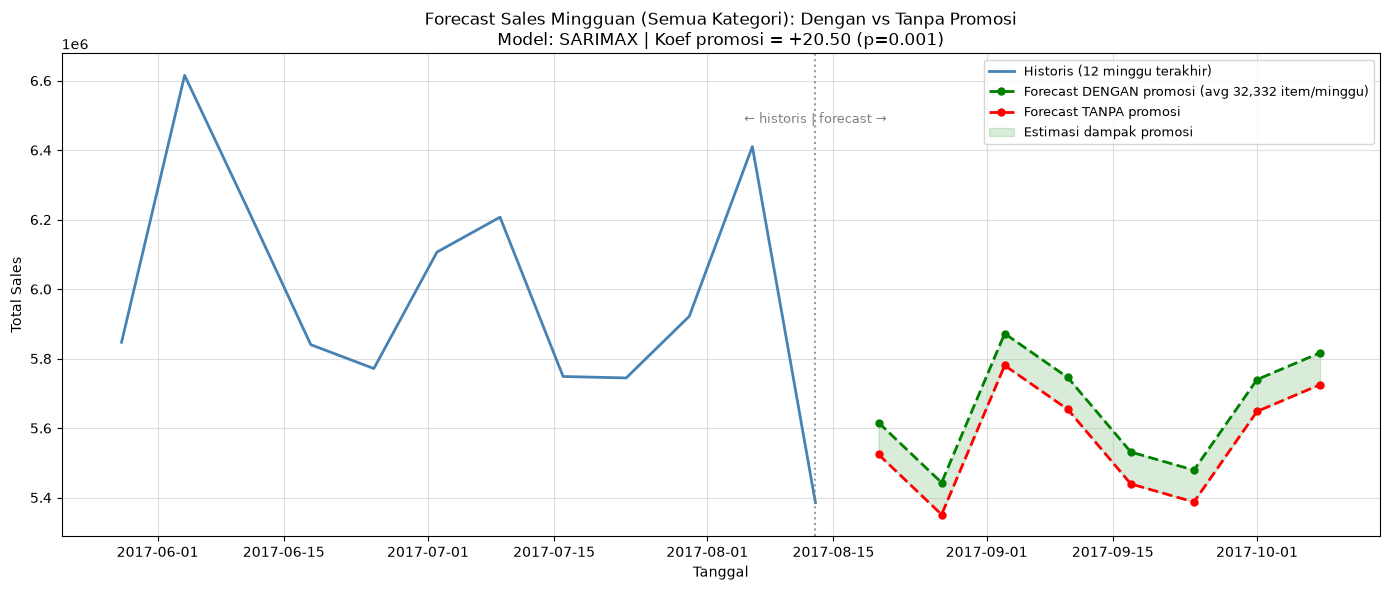

In [69]:
# =========================================================
# VISUALISASI DUA SKENARIO
# =========================================================
history_tail = df_weekly_clean['sales'].tail(12)

plt.figure(figsize=(14, 6))

plt.plot(history_tail.index, history_tail,
         label='Historis (12 minggu terakhir)',
         color='steelblue', linewidth=2)

plt.plot(forecast_dates, forecast_dengan_promo,
         label=f'Forecast DENGAN promosi (avg {avg_promo_all:,.0f} item/minggu)',
         color='green', linewidth=2, linestyle='--', marker='o', markersize=5)

plt.plot(forecast_dates, forecast_tanpa_promo,
         label='Forecast TANPA promosi',
         color='red', linewidth=2, linestyle='--', marker='o', markersize=5)

plt.fill_between(forecast_dates,
                 forecast_tanpa_promo,
                 forecast_dengan_promo,
                 alpha=0.15, color='green',
                 label='Estimasi dampak promosi')

plt.axvline(x=last_date, color='gray', linestyle=':', alpha=0.8)
plt.text(last_date, plt.ylim()[1] * 0.97,
         '← historis | forecast →', ha='center', fontsize=9, color='gray')

plt.title('Forecast Sales Mingguan (Semua Kategori): Dengan vs Tanpa Promosi\n'
          'Model: SARIMAX | Koef promosi = +20.50 (p=0.001)')
plt.xlabel('Tanggal')
plt.ylabel('Total Sales')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [70]:
# =========================================================
# EKSPOR KE TABLEAU
# =========================================================
df_historis = pd.DataFrame({
    'tanggal'  : df_weekly_clean.index,
    'sales'    : df_weekly_clean['sales'].values,
    'tipe'     : 'Historis',
    'skenario' : 'Aktual'
})

df_fc_promo = pd.DataFrame({
    'tanggal'  : forecast_dates,
    'sales'    : forecast_dengan_promo.values,
    'tipe'     : 'Forecast',
    'skenario' : 'Dengan Promosi'
})

df_fc_nopromo = pd.DataFrame({
    'tanggal'  : forecast_dates,
    'sales'    : forecast_tanpa_promo.values,
    'tipe'     : 'Forecast',
    'skenario' : 'Tanpa Promosi'
})

df_export = pd.concat([df_historis, df_fc_promo, df_fc_nopromo])
df_export.to_csv('tableau_forecast_agg.csv', index=False)
print(f"Ekspor selesai: tableau_forecast_agg.csv ({len(df_export)} baris)")
print()
print("Kolom 'skenario': Aktual / Dengan Promosi / Tanpa Promosi")
print("Kolom 'tipe'    : Historis / Forecast")

Ekspor selesai: tableau_forecast_agg.csv (257 baris)

Kolom 'skenario': Aktual / Dengan Promosi / Tanpa Promosi
Kolom 'tipe'    : Historis / Forecast
